# Training with Cleaned Dataset and EDL Type 2
A notebook for training an EfficientNet B3 model with Evidential Deep Learning (EDL Type 2) on a 5-class diabetic retinopathy dataset.
Dataset: `cleaned_dataset` with `train`, `val`, and `test` splits and 0-4 class folders.

## 1. Import Core Libraries

In [28]:
!pip install torch torchvision timm efficientnet-pytorch scikit-learn pandas matplotlib seaborn opencv-python

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

## 2. Define Hyperparameters and Device Configuration

In [29]:
import kagglehub

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Hyperparameters
BATCH_SIZE = 32
LEARNING_RATE = 3e-4
NUM_EPOCHS = 60
NUM_CLASSES = 5
PATIENCE = 15

# Download the dataset using kagglehub
dataset_path = kagglehub.dataset_download('dondirecto/dr-training')
print(f"Dataset path: {dataset_path}")

# Set base paths to point to the local workspace folder
BASE_DIR = os.path.join(dataset_path, 'cleaned_dataset')
TRAIN_DIR = os.path.join(BASE_DIR, 'train')
VAL_DIR = os.path.join(BASE_DIR, 'val')
TEST_DIR = os.path.join(BASE_DIR, 'test')

Using device: cuda
Using Colab cache for faster access to the 'dr-training' dataset.
Dataset path: /kaggle/input/dr-training


## 3. Configure Data Transforms and Loaders

In [30]:
from torch.utils.data import WeightedRandomSampler

import cv2
from PIL import Image

class CLAHETransform:
    def __init__(self, clip_limit=2.0, tile_grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)

    def __call__(self, img):
        img_np = np.array(img)
        lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = self.clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        img_clahe = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2RGB)
        return Image.fromarray(img_clahe)

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.RandomHorizontalFlip(),
        # Vertical flip can create unrealistic retina orientation; keep geometric jitter mild.
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.03, 0.03), scale=(0.97, 1.03)),
        transforms.ColorJitter(brightness=0.08, contrast=0.08),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val_test': transforms.Compose([
        transforms.Resize((300, 300)),
        CLAHETransform(clip_limit=2.0, tile_grid_size=(8, 8)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {
    'train': datasets.ImageFolder(TRAIN_DIR, data_transforms['train']),
    'val': datasets.ImageFolder(VAL_DIR, data_transforms['val_test']),
    'test': datasets.ImageFolder(TEST_DIR, data_transforms['val_test'])
}

train_targets = image_datasets['train'].targets
class_counts = np.bincount(train_targets, minlength=NUM_CLASSES)

# Sampler weights for balancing minibatches
sampler_class_weights = 1.0 / torch.tensor(np.clip(class_counts, 1, None), dtype=torch.float)
sample_weights = sampler_class_weights[train_targets]

# Loss weights for stronger minority-class learning (mean-normalized for stable scale)
class_weights_for_loss = torch.tensor(
    class_counts.sum() / (NUM_CLASSES * np.clip(class_counts, 1, None)),
    dtype=torch.float,
    device=device
 )
class_weights_for_loss = class_weights_for_loss / class_weights_for_loss.mean()

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

dataloaders = {
    'train': DataLoader(image_datasets['train'], batch_size=BATCH_SIZE, sampler=sampler, num_workers=8, pin_memory=True),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Original Class Counts in Train: {class_counts}")
print(f"Sampler Class Weights: {sampler_class_weights}")
print(f"Loss Class Weights (normalized): {class_weights_for_loss}")
print(f"Total Dataset Sizes: {dataset_sizes}")

Classes: ['0', '1', '2', '3', '4']
Original Class Counts in Train: [6777 3712 2568 1321 1545]
Sampler Class Weights: tensor([0.0001, 0.0003, 0.0004, 0.0008, 0.0006])
Loss Class Weights (normalized): tensor([0.3337, 0.6093, 0.8808, 1.7122, 1.4640], device='cuda:0')
Total Dataset Sizes: {'train': 15923, 'val': 2090, 'test': 2426}


## 4. Define Evidential Deep Learning (Type 2) Loss

In [31]:
# Evidential Deep Learning (EDL) Loss Functions

def relu_evidence(y):
    return torch.nn.functional.relu(y)

def exp_evidence(y):
    return torch.exp(torch.clamp(y, -10, 10))

def softplus_evidence(y):
    return torch.nn.functional.softplus(y)

def kl_divergence(alpha, num_classes, device):
    beta = torch.ones([1, num_classes], dtype=torch.float32, device=device)
    S_alpha = torch.sum(alpha, dim=1, keepdim=True)
    S_beta = torch.sum(beta, dim=1, keepdim=True)
    lnB = torch.lgamma(S_alpha) - torch.sum(torch.lgamma(alpha), dim=1, keepdim=True)
    lnB_uni = torch.sum(torch.lgamma(beta), dim=1, keepdim=True) - torch.lgamma(S_beta)
    dg0 = torch.digamma(S_alpha)
    dg1 = torch.digamma(alpha)
    kl = torch.sum((alpha - beta) * (dg1 - dg0), dim=1, keepdim=True) + lnB + lnB_uni
    return kl

def edl_type2_loss(
    output,
    target,
    epoch_num,
    num_classes,
    annealing_step,
    device,
    class_weights=None,
    epsilon=0.1,
    ce_weight=0.4,
    kl_scale=0.05
 ):
    """
    Hybrid loss = EDL + weighted label-smoothed CE.
    This improves class discrimination while preserving uncertainty modeling.
    """
    evidence = softplus_evidence(output)
    alpha = evidence + 1
    S = torch.sum(alpha, dim=1, keepdim=True)

    target_one_hot = torch.eye(num_classes, device=device)[target]
    target_smoothed = target_one_hot * (1.0 - epsilon) + (epsilon / num_classes)

    # EDL data-fit term
    err = torch.sum(target_smoothed * (torch.log(S + 1e-8) - torch.log(alpha + 1e-8)), dim=1, keepdim=True)

    annealing_coef = torch.min(
        torch.tensor(1.0, dtype=torch.float32, device=device),
        torch.tensor(epoch_num / annealing_step, dtype=torch.float32, device=device),
    )

    alpha_tilde = target_smoothed + (1 - target_smoothed) * alpha
    kl = kl_divergence(alpha_tilde, num_classes, device)
    edl_loss = torch.mean(err + (annealing_coef * kl * kl_scale))

    # Weighted CE term to push per-class separation and recover minority classes
    ce_loss = F.cross_entropy(
        output,
        target,
        weight=class_weights,
        label_smoothing=epsilon
    )

    return (1.0 - ce_weight) * edl_loss + ce_weight * ce_loss

## 5. Initialize EfficientNet B3 Model

In [ ]:
class EfficientNetB3EDL(nn.Module):
    def __init__(self, num_classes=5, pretrained=True):
        super(EfficientNetB3EDL, self).__init__()
        if pretrained:
            self.base_model = EfficientNet.from_pretrained('efficientnet-b3')
        else:
            self.base_model = EfficientNet.from_name('efficientnet-b3')

        in_features = self.base_model._fc.in_features

        # Stronger head improves class separation for adjacent DR grades.
        self.base_model._fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Dropout(p=0.35),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.base_model(x)

model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True)
model = model.to(device)

Loaded pretrained weights for efficientnet-b3


## 6. Implement Training and Validation Steps

In [33]:
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
# Switch to Cosine Annealing for smoother learning rate decay
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

def train_model(model, dataloaders, optimizer, scheduler, num_epochs=50):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_loss = 1e10
    best_acc = 0.0
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    # WARM-UP: Freeze the base backbone so we only train the classification head first
    print("Freezing base model for initial warm-up...")
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        # UNFREEZE: Allow deep fine-tuning after 3 epochs
        if epoch == 4:
            print("Unfreezing all layers for deep fine-tuning...")
            for param in model.base_model.parameters():
                param.requires_grad = True
            # Reduce learning rate for fine-tuning so we don't destroy pretrained weights
            for param_group in optimizer.param_groups:
                param_group['lr'] = 1e-4

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            if phase not in dataloaders:
                print(f"{phase} dataloader not found. Skipping.")
                continue

            for inputs, labels in tqdm(dataloaders[phase], desc=phase):
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)

                    # EDL outputs and predictions
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    # Relax the EDL annealing step to 20 for smoother uncertainty learning
                    loss = edl_type2_loss(outputs, labels, epoch, NUM_CLASSES, 20, device)

                    if phase == 'train':
                        loss.backward()
                        # Gradient Clipping: Prevents chaotic gradients from spiking loss early on
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val':
                # Step the Cosine annealing scheduler every epoch based on its internal tracker
                scheduler.step()

                # IMPORTANT: Save model on BEST ACCURACY rather than best loss,
                # as EDL loss can scale unpredictably while still improving accuracy
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), 'best_edl2_efficientnet.pth')
                    print(f" -> Best model saved! (Acc: {best_acc:.4f})")
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= PATIENCE:
            print(f'\nEarly stopping triggered after {epochs_no_improve} epochs without improvement')
            break

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f} | Best val Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, history

## 7. Execute Model Training

In [34]:
# Execute this block to train
if 'train' in dataloaders and 'val' in dataloaders:
    print("Starting Training...")
    model, history = train_model(model, dataloaders, optimizer, scheduler, num_epochs=NUM_EPOCHS)
else:
    print("Dataloaders not initialized mapping to physical files. Please review paths.")

Starting Training...
Freezing base model for initial warm-up...
Epoch 1/60
----------


train: 100%|██████████| 498/498 [00:45<00:00, 10.90it/s]


Train Loss: 1.4372 Acc: 0.4444


val: 100%|██████████| 66/66 [00:05<00:00, 11.11it/s]


Val Loss: 1.3143 Acc: 0.5703
 -> Best model saved! (Acc: 0.5703)

Epoch 2/60
----------


...

Val Loss: 1.1750 Acc: 0.7670

Epoch 21/60
----------


train: 100%|██████████| 498/498 [01:21<00:00,  6.10it/s]


Train Loss: 0.6742 Acc: 0.9891


val: 100%|██████████| 66/66 [00:05<00:00, 11.56it/s]

Val Loss: 1.2343 Acc: 0.7517

Early stopping triggered after 15 epochs without improvement
Training complete in 28m 49s
Best val Acc: 0.7828 | Best val Loss: 1.0604


## 8. Evaluate on Test Dataset and Extract Uncertainty

Testing: 100%|██████████| 76/76 [00:06<00:00, 11.32it/s]



Test Accuracy: 0.5606

Classification Report:
              precision    recall  f1-score   support

           0     0.8623    0.9554    0.9065       852
           1     0.2200    0.5023    0.3059       215
           2     0.5095    0.1770    0.2627       757
           3     0.4662    0.3764    0.4165       348
           4     0.3870    0.6811    0.4936       254

    accuracy                         0.5606      2426
   macro avg     0.4890    0.5385    0.4771      2426
weighted avg     0.5887    0.5606    0.5389      2426



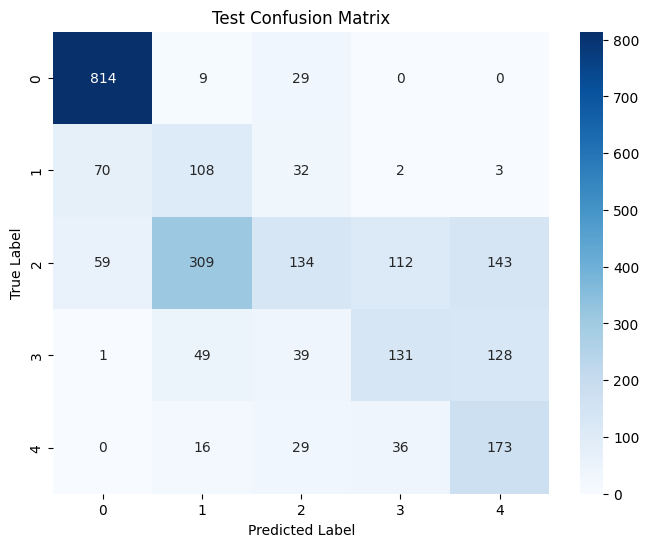

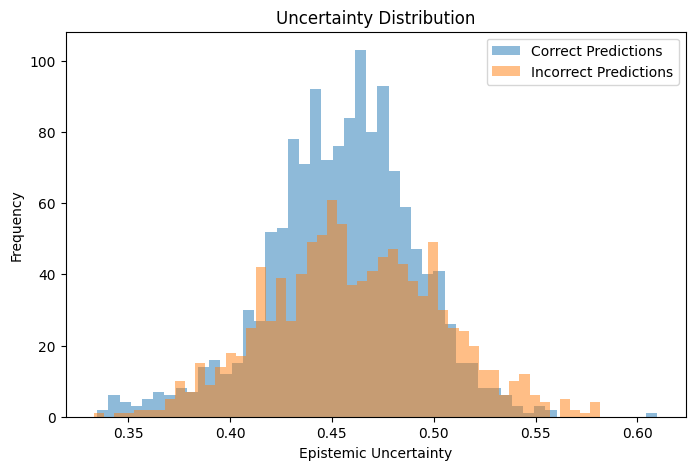

In [35]:
def evaluate_edl_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    all_uncertainties = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            evidence = softplus_evidence(outputs)
            alpha = evidence + 1
            S = torch.sum(alpha, dim=1, keepdim=True)

            # Epistemic Uncertainty = K / S
            u = NUM_CLASSES / S

            _, preds = torch.max(alpha, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(u.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)

if 'test' in dataloaders:
    y_true, y_pred, uncertainties = evaluate_edl_model(model, dataloaders['test'])

    acc = accuracy_score(y_true, y_pred)
    print(f"\nTest Accuracy: {acc:.4f}")
    print("\nClassification Report:")
    try:
        print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    except:
        print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Test Confusion Matrix')
    plt.show()

    # Uncertainty visualization
    plt.figure(figsize=(8,5))
    plt.hist(uncertainties[y_true == y_pred], bins=50, alpha=0.5, label='Correct Predictions')
    plt.hist(uncertainties[y_true != y_pred], bins=50, alpha=0.5, label='Incorrect Predictions')
    plt.xlabel('Epistemic Uncertainty')
    plt.ylabel('Frequency')
    plt.legend()
    plt.title('Uncertainty Distribution')
    plt.show()

## 9. Download the Best Model Checkpoint
Execute this cell to download the `.pth` file to your local machine before the hosted runtime shuts down.

In [36]:
import os

model_path = 'best_edl2_efficientnet.pth'

if os.path.exists(model_path):
    try:
        # Colab Specific Download
        from google.colab import files
        print("Running in Google Colab. Initiating download...")
        files.download(model_path)
    except ImportError:
        # Universal Jupyter/Kaggle Download Link
        from IPython.display import FileLink, display
        print("Not in Colab. Creating a universal download link...")
        display(FileLink(model_path, result_html_prefix="Click here to download: "))
else:
    print(f"Model file '{model_path}' not found. Make sure your training loop actually completed and saved.")

Running in Google Colab. Initiating download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. K-Fold Cross-Validation (Stratified) and Fold Checkpoints
This section trains multiple folds on the training split and saves one best checkpoint per fold (`best_fold_1.pth`, ..., `best_fold_k.pth`).

Why this helps:
- Reduces dependency on one lucky/unlucky split
- Improves robustness for minority grades
- Produces diverse checkpoints for ensembling

In [ ]:
from sklearn.model_selection import StratifiedKFold
from torch.utils.data import Subset


def build_optimizer_and_scheduler(model, total_epochs):
    optimizer = optim.AdamW(
        [
            {'params': model.base_model._fc.parameters(), 'lr': 1e-3},
            {'params': [p for n, p in model.base_model.named_parameters() if not n.startswith('_fc')], 'lr': 3e-4},
        ],
        weight_decay=1e-4
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_epochs, eta_min=1e-6)
    return optimizer, scheduler


def make_fold_weights(train_targets_fold, num_classes, device):
    class_counts_fold = np.bincount(train_targets_fold, minlength=num_classes)

    sampler_class_weights_fold = 1.0 / torch.tensor(np.clip(class_counts_fold, 1, None), dtype=torch.float)
    sample_weights_fold = sampler_class_weights_fold[train_targets_fold]

    loss_weights_fold = torch.tensor(
        class_counts_fold.sum() / (num_classes * np.clip(class_counts_fold, 1, None)),
        dtype=torch.float,
        device=device,
    )
    loss_weights_fold = loss_weights_fold / loss_weights_fold.mean()

    return sample_weights_fold, loss_weights_fold, class_counts_fold


def train_one_fold(model, dataloaders_fold, dataset_sizes_fold, optimizer, scheduler, loss_weights_fold, num_epochs=35, patience=10, checkpoint_path='best_fold.pth'):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_f1 = 0.0
    best_acc = 0.0
    best_loss = 1e10
    epochs_no_improve = 0

    # Warm-up head only
    for param in model.base_model.parameters():
        param.requires_grad = False
    for param in model.base_model._fc.parameters():
        param.requires_grad = True

    for epoch in range(1, num_epochs + 1):
        print(f'Fold Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        if epoch == 4:
            for param in model.base_model.parameters():
                param.requires_grad = True
            optimizer.param_groups[0]['lr'] = 2e-4
            optimizer.param_groups[1]['lr'] = 5e-5

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()

            running_loss = 0.0
            running_corrects = 0
            all_preds = []
            all_labels = []

            for inputs, labels in tqdm(dataloaders_fold[phase], desc=f'{phase}'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    evidence = softplus_evidence(outputs)
                    alpha = evidence + 1
                    _, preds = torch.max(alpha, 1)

                    loss = edl_type2_loss(
                        outputs, labels, epoch, NUM_CLASSES, 25, device,
                        class_weights=loss_weights_fold,
                        epsilon=0.1,
                        ce_weight=0.45,
                        kl_scale=0.03,
                    )

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                all_preds.extend(preds.detach().cpu().numpy())
                all_labels.extend(labels.detach().cpu().numpy())

            epoch_loss = running_loss / dataset_sizes_fold[phase]
            epoch_acc = running_corrects.double() / dataset_sizes_fold[phase]
            epoch_f1 = f1_score(all_labels, all_preds, average='macro')

            print(f'{phase.capitalize()} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} Macro-F1: {epoch_f1:.4f}')

            if phase == 'val':
                scheduler.step()
                if epoch_f1 > best_f1:
                    best_f1 = epoch_f1
                    best_acc = epoch_acc.item()
                    best_loss = epoch_loss
                    best_model_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                    torch.save(model.state_dict(), checkpoint_path)
                    print(f' -> Best fold checkpoint saved: {checkpoint_path} (Macro-F1: {best_f1:.4f})')
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f'Early stop for fold: no macro-F1 improvement for {patience} epochs')
            break

    time_elapsed = time.time() - since
    print(f'Fold training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best fold Macro-F1: {best_f1:.4f} | Acc: {best_acc:.4f} | Loss: {best_loss:.4f}')

    model.load_state_dict(best_model_wts)
    return model, best_f1, best_acc, best_loss


RUN_KFOLD = False
KFOLDS = 5
FOLD_EPOCHS = 35

if RUN_KFOLD:
    base_train_dataset_aug = datasets.ImageFolder(TRAIN_DIR, data_transforms['train'])
    base_train_dataset_eval = datasets.ImageFolder(TRAIN_DIR, data_transforms['val_test'])
    fold_targets = np.array(base_train_dataset_aug.targets)

    skf = StratifiedKFold(n_splits=KFOLDS, shuffle=True, random_state=SEED)

    fold_results = []
    fold_checkpoint_paths = []

    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(fold_targets)), fold_targets), start=1):
        print(f'\n===== Fold {fold_idx}/{KFOLDS} =====')

        train_targets_fold = fold_targets[train_idx]
        sample_weights_fold, loss_weights_fold, class_counts_fold = make_fold_weights(train_targets_fold, NUM_CLASSES, device)

        train_subset = Subset(base_train_dataset_aug, train_idx.tolist())
        val_subset = Subset(base_train_dataset_eval, val_idx.tolist())

        fold_train_sampler = WeightedRandomSampler(
            weights=sample_weights_fold,
            num_samples=len(sample_weights_fold),
            replacement=True,
        )

        fold_loaders = {
            'train': DataLoader(train_subset, batch_size=BATCH_SIZE, sampler=fold_train_sampler, num_workers=8, pin_memory=True),
            'val': DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True),
        }
        fold_sizes = {'train': len(train_subset), 'val': len(val_subset)}

        fold_model = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=True).to(device)
        fold_optimizer, fold_scheduler = build_optimizer_and_scheduler(fold_model, FOLD_EPOCHS)

        fold_ckpt = f'best_fold_{fold_idx}.pth'
        _, fold_f1, fold_acc, fold_loss = train_one_fold(
            fold_model,
            fold_loaders,
            fold_sizes,
            fold_optimizer,
            fold_scheduler,
            loss_weights_fold,
            num_epochs=FOLD_EPOCHS,
            patience=max(8, PATIENCE // 2),
            checkpoint_path=fold_ckpt,
        )

        fold_checkpoint_paths.append(fold_ckpt)
        fold_results.append({'fold': fold_idx, 'macro_f1': fold_f1, 'acc': fold_acc, 'loss': fold_loss, 'class_counts': class_counts_fold.tolist()})

    print('\n===== K-Fold Summary =====')
    for fr in fold_results:
        print(f"Fold {fr['fold']}: Macro-F1={fr['macro_f1']:.4f}, Acc={fr['acc']:.4f}, Loss={fr['loss']:.4f}")
    print(f"Mean Macro-F1: {np.mean([x['macro_f1'] for x in fold_results]):.4f}")
    print(f"Saved checkpoints: {fold_checkpoint_paths}")
else:
    print('K-Fold is configured. Set RUN_KFOLD = True to start fold training.')

## 11. Checkpoint Ensembling on Test Set
This section loads all fold checkpoints and ensembles them by averaging evidential alpha outputs.

Why this helps:
- Reduces variance from individual folds
- Usually improves macro-F1 and worst-class recall
- More stable than single-checkpoint predictions

In [ ]:
import glob


def load_fold_models(checkpoint_paths, device):
    ensemble_models = []
    for ckpt_path in checkpoint_paths:
        if not os.path.exists(ckpt_path):
            print(f'Skipping missing checkpoint: {ckpt_path}')
            continue
        m = EfficientNetB3EDL(num_classes=NUM_CLASSES, pretrained=False).to(device)
        m.load_state_dict(torch.load(ckpt_path, map_location=device))
        m.eval()
        ensemble_models.append(m)
    return ensemble_models


def evaluate_ensemble(models, dataloader):
    all_preds, all_labels, all_uncertainties = [], [], []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc='Ensemble Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)

            alpha_sum = None
            for m in models:
                logits = m(inputs)
                alpha = softplus_evidence(logits) + 1
                alpha_sum = alpha if alpha_sum is None else alpha_sum + alpha

            alpha_avg = alpha_sum / len(models)
            S = torch.sum(alpha_avg, dim=1, keepdim=True)
            uncertainty = NUM_CLASSES / S
            _, preds = torch.max(alpha_avg, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_uncertainties.extend(uncertainty.squeeze().cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_uncertainties)


USE_ENSEMBLE = True

if USE_ENSEMBLE:
    candidate_ckpts = sorted(glob.glob('best_fold_*.pth'))
    if len(candidate_ckpts) == 0:
        print('No fold checkpoints found. Run Cell 10 first with RUN_KFOLD = True.')
    else:
        print(f'Found fold checkpoints: {candidate_ckpts}')
        ensemble_models = load_fold_models(candidate_ckpts, device)

        if len(ensemble_models) == 0:
            print('No valid checkpoints could be loaded.')
        elif 'test' not in dataloaders:
            print('Test dataloader not found.')
        else:
            y_true_e, y_pred_e, u_e = evaluate_ensemble(ensemble_models, dataloaders['test'])

            acc_e = accuracy_score(y_true_e, y_pred_e)
            macro_f1_e = f1_score(y_true_e, y_pred_e, average='macro')
            weighted_f1_e = f1_score(y_true_e, y_pred_e, average='weighted')

            print(f"\nEnsemble Test Accuracy: {acc_e:.4f}")
            print(f"Ensemble Test Macro-F1: {macro_f1_e:.4f}")
            print(f"Ensemble Test Weighted-F1: {weighted_f1_e:.4f}")
            print('\nEnsemble Classification Report:')
            try:
                print(classification_report(y_true_e, y_pred_e, target_names=class_names, digits=4))
            except Exception:
                print(classification_report(y_true_e, y_pred_e, digits=4))

            cm_e = confusion_matrix(y_true_e, y_pred_e)
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.title('Ensemble Test Confusion Matrix')
            plt.show()

            plt.figure(figsize=(8, 5))
            plt.hist(u_e[y_true_e == y_pred_e], bins=50, alpha=0.5, label='Correct Predictions')
            plt.hist(u_e[y_true_e != y_pred_e], bins=50, alpha=0.5, label='Incorrect Predictions')
            plt.xlabel('Epistemic Uncertainty')
            plt.ylabel('Frequency')
            plt.legend()
            plt.title('Ensemble Uncertainty Distribution')
            plt.show()